In [254]:
!pip install  pandas  -q 
!pip install  kaggle -q 
!pip install scikit-learn -q 
!pip install numpy -q 
!pip install matplotlib -q 
!pip install plotly -q 
!pip install seaborn -q 

In [255]:
# dowload  dataset  from kaggle 
!kaggle competitions download -c playground-series-s5e3

100%|███████████████████████████████████████| 59.0k/59.0k [00:00<00:00, 367kB/s]
100%|███████████████████████████████████████| 59.0k/59.0k [00:00<00:00, 367kB/s]


In [256]:
# unzip  dataset 
!unzip  -o 'playground-series-s5e3.zip' 
!rm playground-series-s5e3.zip

Archive:  playground-series-s5e3.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [257]:
import pandas as pd 
import sklearn 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [258]:
# impoort dataset 

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_df  = pd.read_csv('sample_submission.csv') 

In [259]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [260]:
train_df.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='object')

In [261]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [262]:
train_df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [263]:
train_df.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

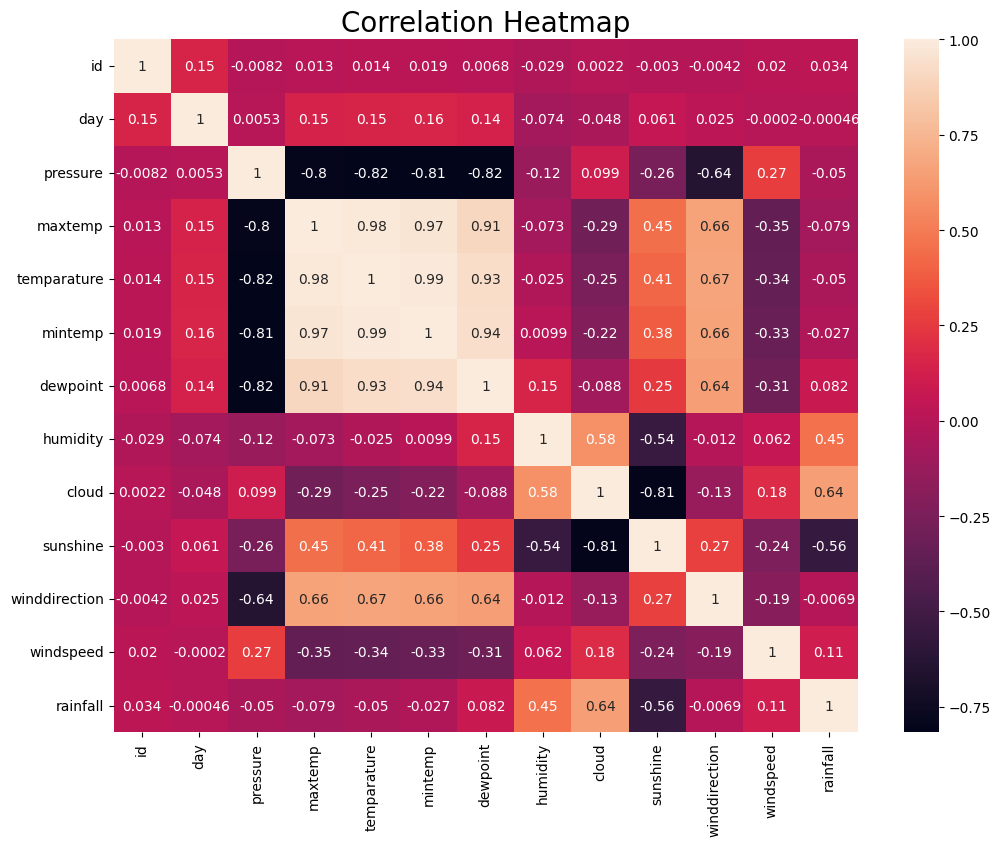

In [264]:
# plot correlation 
train_df_corr = train_df.corr()

# set up the matplotlib figure 
f, ax = plt.subplots(figsize=(12, 9))
plt.title('Correlation Heatmap', fontsize=20)
#plotting the heatmap for correlation
ax = sns.heatmap(train_df.corr(), annot=True)

In [265]:
# feature selection 
train_df = train_df.drop(['id'], axis = 1)
train_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [266]:
train_df.shape

(2190, 12)

## Training model

In [267]:
# split data 
X = train_df.drop('rainfall', axis = 1) 
y = train_df['rainfall']

In [268]:
X.shape, y.shape

((2190, 11), (2190,))

In [281]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score


# Define the base models
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),  
    # Set probability=True for ROC AUC
]
    
# Create the Stacking Classifier
stacked_model = StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression())

# Fit the Stacking Model
stacked_model.fit(X_train, y_train)

# Make predictions (for ROC AUC, we typically use predicted probabilities)
y_pred_prob = stacked_model.predict_proba(X_test)[:, 1]

# Evaluate the model using ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print('ROC AUC:', roc_auc)

ROC AUC: 0.837085601187531


## perdict test data 

In [283]:
test_df.head(3)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9


In [284]:
test_df['winddirection'] = test_df['winddirection'].fillna(test_df['winddirection'].mean())
# fuill missing value

In [285]:
test_df.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [286]:
#predict test data
test_df = test_df.drop(['id',], axis = 1)
test_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [287]:
test_df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

In [288]:
#predict test data
y_pred = stacked_model.predict(test_df)

In [289]:
# save the predictions to a csv file
test_df = pd.read_csv('test.csv')
submission = pd.DataFrame({'id': test_df['id'], 'rainfall': y_pred})
submission.to_csv('submission.csv', index=False)

In [290]:
submission.head()

,id,rainfall
0,2190,1
1,2191,1
2,2192,1
3,2193,0
4,2194,0


In [291]:
# sumiting to kaggle 
!kaggle competitions submit -c playground-series-s5e3 -f 'submission.csv' -m 'acc 0.86'

100%|██████████████████████████████████████| 5.00k/5.00k [00:01<00:00, 4.56kB/s]
Successfully submitted to Binary Prediction with a Rainfall Dataset

In [1]:
# remove files 
!rm 'train.csv'
!rm 'test.csv'
!rm 'sample_submission.csv'
!rm 'submission.csv' 